# Codenames Spymaster Results

Every number here comes from `cache/llm_store.db`, which stores every game
already played. Nothing is re-run and no API calls are made.

All games use **Claude Sonnet 5 as the guesser** for both sides, and every
matchup plays each board twice with the sides swapped, because team A holds 9
words and moves first while team B holds 8 — a one-sided run would confound
spymaster strength with that advantage.

Three families of model appear:

| Model | What it does |
|---|---|
| `centroid` | Picks the clue closest to the centre of a group of own words. The simple baseline. |
| `expected_words` | Maximises expected reward under a Gaussian model of guesser noise, with one free parameter σ. |
| `learned_listener` | Maximises expected reward under a *learned* model of the guesser, distilled from an LLM. |

In [1]:
import json
import sqlite3
from collections import defaultdict
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

DB = Path("../cache/llm_store.db")

# Okabe-Ito: colourblind-safe by construction, so it needs no validation pass.
# Hues are assigned to entities in a fixed order and never cycled, so a model
# keeps its colour across every chart below.
BLUE, ORANGE, GREEN, VERM, PURPLE, SKY = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9"
ROLE_COLOR = {"own": GREEN, "neutral": "#9AA0A6", "opponent": ORANGE, "assassin": VERM}
INK, MUTED = "#202124", "#5F6368"

mpl.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 130,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#C8CCD0", "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": "#E8EAED", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "font.size": 9, "legend.frameon": False,
})


def wilson(k, n, z=1.96):
    """95% interval on a win rate. Wilson rather than normal-approximation
    because several of these runs are only 40 games."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return max(0.0, c - h), min(1.0, c + h)


def load(db=DB):
    """One row per (label, seed), keeping the newest.

    The sigma=1.5 matchup was extended from 20 boards to 50 after the fact, so
    its first 20 seeds are present twice; without this they would be counted
    twice and weighted double."""
    con = sqlite3.connect(db)
    rows = con.execute(
        "select id, label, seed, winner, turns from game_records order by id"
    ).fetchall()
    best = {}
    for gid, label, seed, winner, turns in rows:
        best[(label, seed)] = (winner, turns)
    return best


GAMES = load()
print(f"{len(GAMES)} unique games in cache")

807 unique games in cache


## Pulling per-spymaster statistics out of the turn logs

Each stored game holds the full turn history: who moved, the clue and number,
every word guessed and what it turned out to be. That is enough to recover
every statistic below without replaying anything.

In [2]:
def side_names(label):
    """'run|A=centroid,B=expected_words' -> ('centroid', 'expected_words')."""
    _, _, sides = label.partition("|")
    a, _, b = sides.partition(",")
    return a.split("=", 1)[1], b.split("=", 1)[1]


def collect(label_filter):
    """Aggregate every game whose label satisfies `label_filter`.

    Returns {spymaster: stats}, where a 'win' is credited to the spymaster
    sitting on the winning side."""
    agg = defaultdict(lambda: {"games": 0, "wins": 0, "clues": 0, "k_sum": 0,
                               "assassin_games": 0, "reward_sum": 0.0,
                               "guesses": defaultdict(int), "opponents": set()})
    for (label, seed), (winner, turns) in GAMES.items():
        if not label_filter(label) or "|" not in label:
            continue
        names = side_names(label)
        won = names[0] if str(winner).upper().endswith("A") else names[1]
        for nm in names:
            agg[nm]["games"] += 1
            agg[nm]["opponents"].add(names[1] if nm == names[0] else names[0])
        agg[won]["wins"] += 1
        for t in json.loads(turns):
            who = names[0] if str(t.get("team", "")).upper() == "A" else names[1]
            agg[who]["clues"] += 1
            agg[who]["k_sum"] += t.get("number", 0) or 0
            for _, role in t.get("guesses", []):
                agg[who]["guesses"][role] += 1
                agg[who]["reward_sum"] += REWARD.get(role, 0.0)
            if t.get("ended_reason") == "assassin":
                agg[who]["assassin_games"] += 1
    for s in agg.values():
        s["mean_k"] = s["k_sum"] / max(s["clues"], 1)
        # Per-TURN rates: a turn is one clue, so these divide by clue count.
        n_turns = max(s["clues"], 1)
        s["own_per_turn"] = s["guesses"]["own"] / n_turns
        s["advantage_per_turn"] = (s["guesses"]["own"] - s["guesses"]["opponent"]) / n_turns
        s["reward_per_turn"] = s["reward_sum"] / n_turns
        s["win_rate"] = s["wins"] / max(s["games"], 1)
        s["assassin_rate"] = s["assassin_games"] / max(s["games"], 1)
        tot = sum(s["guesses"].values())
        s["guess_pct"] = {r: s["guesses"][r] / max(tot, 1) for r in ROLE_COLOR}
        s["ci"] = wilson(s["wins"], s["games"])
    return dict(agg)


# The game's own scoring, used for reward per turn: every own word a turn
# reveals is worth +1, and a turn that ends on someone else's word is charged
# for it. The assassin at -10 is what makes caution worth paying for.
REWARD = {"own": 1.0, "neutral": -0.2, "opponent": -1.0, "assassin": -10.0}

# The sigma ladder: each value of sigma played head-to-head against centroid.
LADDER = {
    "σ = 1.0":  lambda l: "sigma=1.0]-vs-centroid" in l,
    "σ = 1.25": lambda l: "sigma=1.25]-vs-centroid" in l,
    "σ = 1.5":  lambda l: "sigma=1.5]-vs-centroid" in l,
    "σ = 2.0":  lambda l: "sigma=2.0]-vs-centroid" in l,
    "σ = 2.5":  lambda l: l.startswith("centroid-vs-expected_words+"),
}
ladder = {}
for tag, f in LADDER.items():
    st = collect(f)
    ew = [k for k in st if k.startswith("expected_words")]
    if ew:
        ladder[tag] = st[ew[0]]
        print(f"{tag:8s} {ladder[tag]['games']:3d} games vs centroid  "
              f"win {ladder[tag]['win_rate']:.0%}  mean k {ladder[tag]['mean_k']:.2f}")

σ = 1.0  100 games vs centroid  win 69%  mean k 2.67
σ = 1.25 100 games vs centroid  win 70%  mean k 2.27
σ = 1.5  100 games vs centroid  win 70%  mean k 1.93
σ = 2.0  100 games vs centroid  win 57%  mean k 1.42
σ = 2.5  100 games vs centroid  win 51%  mean k 1.16


## 1. Which noise level is best?

`expected_words` assumes the guesser perceives each word's similarity with
Gaussian noise of scale σ. Small σ means "trust the guesser to rank words the
way I do"; large σ means "assume they are unreliable and play safe". The value
is a free parameter, so it was swept and each setting played 100 games against
the same opponent.

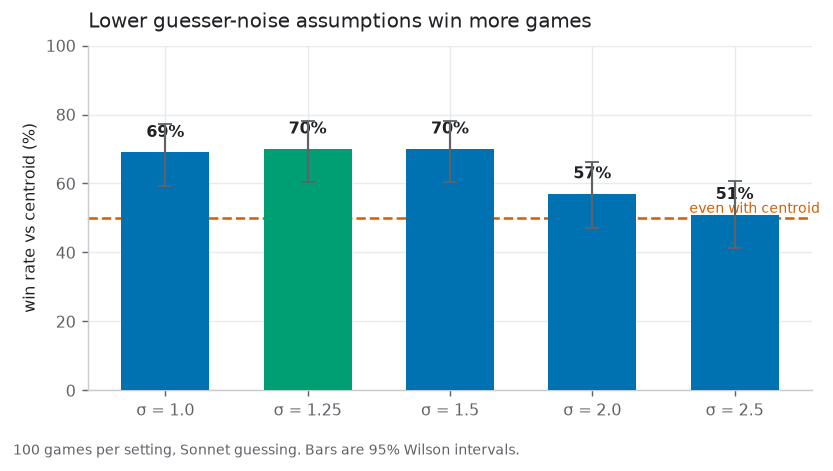

In [3]:
tags = list(ladder)
wr = np.array([ladder[t]["win_rate"] for t in tags])
lo = np.array([ladder[t]["ci"][0] for t in tags])
hi = np.array([ladder[t]["ci"][1] for t in tags])
best = int(np.argmax(wr))

fig, ax = plt.subplots(figsize=(6.4, 3.4))
cols = [BLUE if i != best else GREEN for i in range(len(tags))]
ax.bar(tags, wr * 100, color=cols, width=0.62, zorder=3)
ax.errorbar(tags, wr * 100, yerr=[(wr - lo) * 100, (hi - wr) * 100],
            fmt="none", ecolor=MUTED, elinewidth=1.2, capsize=4, zorder=4)
ax.axhline(50, color=VERM, lw=1.4, ls="--", zorder=2)
ax.text(len(tags) - 0.4, 51.5, "even with centroid", color=VERM, fontsize=8, ha="right")
for i, v in enumerate(wr):
    ax.text(i, v * 100 + 4.5, f"{v:.0%}", ha="center", fontsize=9, color=INK, fontweight="bold")
ax.set_ylabel("win rate vs centroid (%)")
ax.set_ylim(0, 100)
ax.set_title("Lower guesser-noise assumptions win more games", loc="left", fontsize=11, pad=10)
fig.text(0.01, -0.04, "100 games per setting, Sonnet guessing. Bars are 95% Wilson intervals.",
         fontsize=8, color=MUTED)
plt.tight_layout(); plt.show()

The model plays best when it assumes the guesser is *fairly reliable*
(σ ≈ 1.0–1.5) and degrades once it assumes too much noise. The shipped default
had been σ = 2.5 — the worst setting tested.

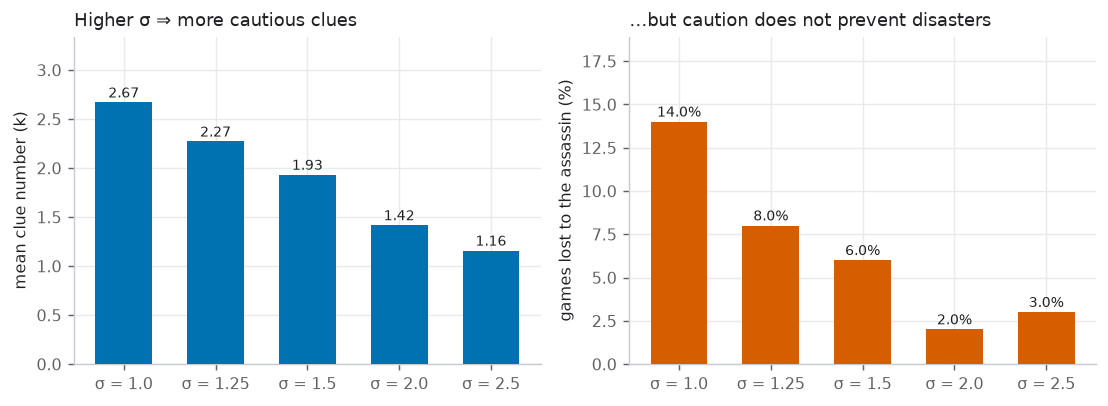

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.2))
mk = [ladder[t]["mean_k"] for t in tags]
axes[0].bar(tags, mk, color=BLUE, width=0.62, zorder=3)
for i, v in enumerate(mk):
    axes[0].text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=8, color=INK)
axes[0].set_ylabel("mean clue number (k)")
axes[0].set_title("Higher σ ⇒ more cautious clues", loc="left", fontsize=10)
axes[0].set_ylim(0, max(mk) * 1.25)

ar = [ladder[t]["assassin_rate"] * 100 for t in tags]
axes[1].bar(tags, ar, color=VERM, width=0.62, zorder=3)
for i, v in enumerate(ar):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=8, color=INK)
axes[1].set_ylabel("games lost to the assassin (%)")
axes[1].set_title("…but caution does not prevent disasters", loc="left", fontsize=10)
axes[1].set_ylim(0, max(ar) * 1.35 if max(ar) else 1)
plt.tight_layout(); plt.show()

## 2. The learned listener against three opponents

`learned_listener` replaces the Gaussian noise assumption with a model trained
to imitate an actual LLM guesser. It was played against three opponents: the
simple `centroid` baseline, `expected_words` at its old default σ = 2.5, and
`expected_words` at the best setting found above, σ = 1.5.

In [5]:
MATCHUPS = {
    "vs centroid":        lambda l: "learned_listener_vs_centroid" in l,
    "vs σ=2.5 baseline":  lambda l: "learned_listener_vs_expected_words_sonnet" in l,
    "vs σ=1.5 baseline":  lambda l: "learned_listener_vs_expected_words_sigma1.5" in l,
}
head = {}
for tag, f in MATCHUPS.items():
    st = collect(f)
    head[tag] = {nm: s for nm, s in st.items()}
    ll = st["learned_listener"]
    print(f"{tag:20s} {ll['games']:3d} games  win {ll['win_rate']:.0%}  "
          f"95% CI [{ll['ci'][0]:.2f}, {ll['ci'][1]:.2f}]")

vs centroid           40 games  win 82%  95% CI [0.68, 0.91]
vs σ=2.5 baseline     40 games  win 90%  95% CI [0.77, 0.96]
vs σ=1.5 baseline    100 games  win 72%  95% CI [0.63, 0.80]


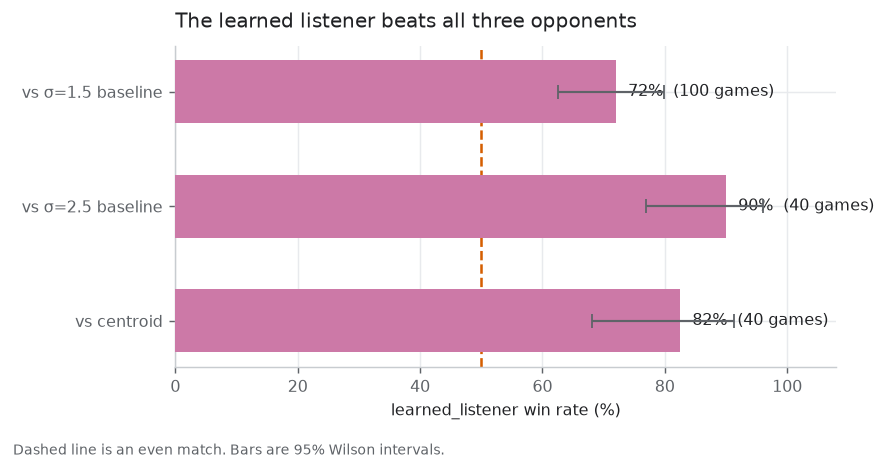

In [6]:
tags2 = list(head)
wr2 = np.array([head[t]["learned_listener"]["win_rate"] for t in tags2])
lo2 = np.array([head[t]["learned_listener"]["ci"][0] for t in tags2])
hi2 = np.array([head[t]["learned_listener"]["ci"][1] for t in tags2])
n2 = [head[t]["learned_listener"]["games"] for t in tags2]

fig, ax = plt.subplots(figsize=(6.8, 3.4))
ax.barh(tags2, wr2 * 100, color=PURPLE, height=0.55, zorder=3)
ax.errorbar(wr2 * 100, tags2, xerr=[(wr2 - lo2) * 100, (hi2 - wr2) * 100],
            fmt="none", ecolor=MUTED, elinewidth=1.2, capsize=4, zorder=4)
ax.axvline(50, color=VERM, lw=1.4, ls="--", zorder=2)
for i, (v, n) in enumerate(zip(wr2, n2)):
    ax.text(v * 100 + 2, i, f"{v:.0%}  ({n} games)", va="center", fontsize=9, color=INK)
ax.set_xlabel("learned_listener win rate (%)")
ax.set_xlim(0, 108)
ax.set_title("The learned listener beats all three opponents", loc="left", fontsize=11, pad=10)
fig.text(0.01, -0.04, "Dashed line is an even match. Bars are 95% Wilson intervals.",
         fontsize=8, color=MUTED)
plt.tight_layout(); plt.show()

The margin shrinks sharply once the baseline is properly configured — beating
σ = 2.5 is largely beating a bad setting, while σ = 1.5 is a real opponent.

## 3. What the guesses actually look like

Win rate says who won; this says *how*. Every guess a spymaster's clues
produced, split by what the word turned out to be.

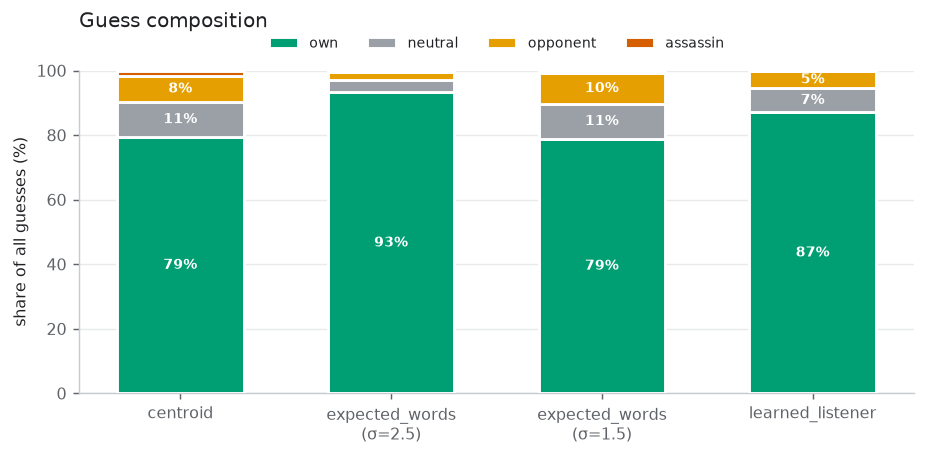

In [7]:
panel = {
    "centroid": collect(lambda l: "learned_listener_vs_centroid" in l)["centroid"],
    "expected_words\n(σ=2.5)": ladder["σ = 2.5"],
    "expected_words\n(σ=1.5)": ladder["σ = 1.5"],
    "learned_listener": head["vs σ=1.5 baseline"]["learned_listener"],
}
names = list(panel)
order = ["own", "neutral", "opponent", "assassin"]
fig, ax = plt.subplots(figsize=(7.2, 3.6))
bottom = np.zeros(len(names))
for role in order:
    vals = np.array([panel[n]["guess_pct"][role] * 100 for n in names])
    ax.bar(names, vals, bottom=bottom, color=ROLE_COLOR[role], width=0.6,
           label=role, zorder=3, edgecolor="white", linewidth=1.6)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 4:
            ax.text(i, b + v / 2, f"{v:.0f}%", ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold")
    bottom += vals
ax.set_ylabel("share of all guesses (%)")
ax.set_ylim(0, 100)
ax.legend(ncol=4, loc="lower center", bbox_to_anchor=(0.5, 1.02), fontsize=8)
ax.set_title("Guess composition", loc="left", fontsize=11, pad=24)
plt.tight_layout(); plt.show()

## 5. Per-turn efficiency

Win rate says who won and guess composition says how accurate the clues were,
but neither says how much a turn actually *achieves*. These three do, all
averaged per turn (a turn is one clue):

- **own cards per turn** — how many of our words the guesser gets before the
  turn ends. Raw productivity.
- **card advantage per turn** — own cards minus opponent cards. Handing the
  other team a word is worth roughly as much to them as taking one is to us,
  so this is the net swing.
- **reward per turn** — the game's own scoring: +1 per own word, −0.2 neutral,
  −1 opponent, −10 assassin. The assassin term is what separates a model that
  is merely productive from one that is safe.

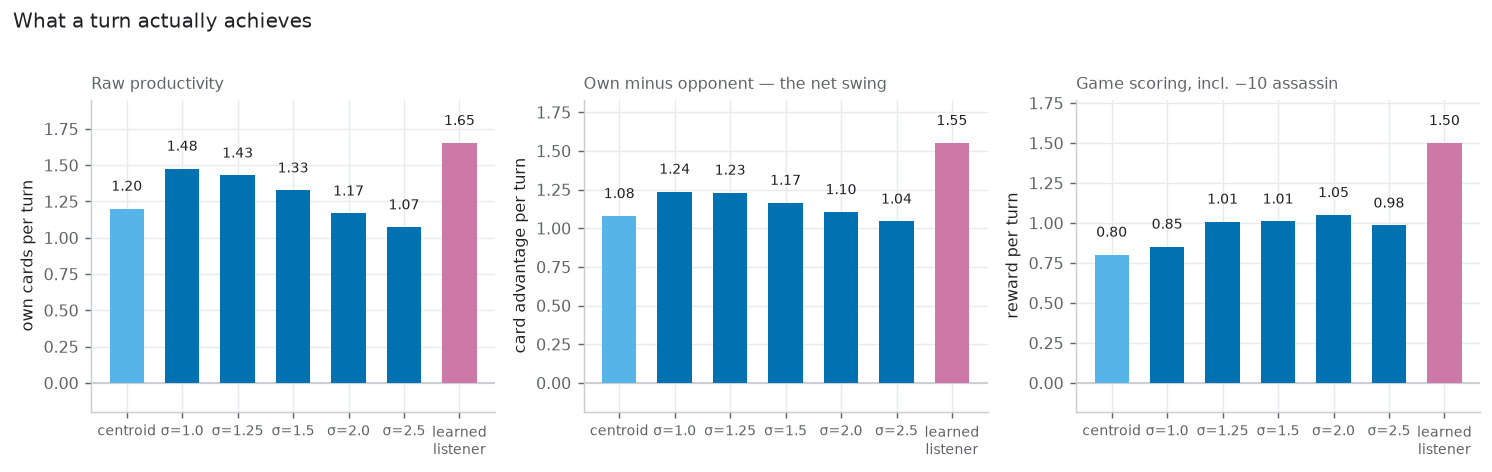

model             own/turn  advantage/turn  reward/turn
-------------------------------------------------------
centroid              1.20            1.08         0.80
σ=1.0                 1.48            1.24         0.85
σ=1.25                1.43            1.23         1.01
σ=1.5                 1.33            1.17         1.01
σ=2.0                 1.17            1.10         1.05
σ=2.5                 1.07            1.04         0.98
learned listener      1.65            1.55         1.50


In [8]:
PANEL = [("centroid", panel["centroid"]),
         ("σ=1.0", ladder["σ = 1.0"]), ("σ=1.25", ladder["σ = 1.25"]),
         ("σ=1.5", ladder["σ = 1.5"]), ("σ=2.0", ladder["σ = 2.0"]),
         ("σ=2.5", ladder["σ = 2.5"]),
         ("learned\nlistener", head["vs σ=1.5 baseline"]["learned_listener"])]
labels = [n for n, _ in PANEL]
cols = [SKY] + [BLUE] * 5 + [PURPLE]

metrics = [("own_per_turn", "own cards per turn", "Raw productivity"),
           ("advantage_per_turn", "card advantage per turn", "Own minus opponent — the net swing"),
           ("reward_per_turn", "reward per turn", "Game scoring, incl. −10 assassin")]

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.5))
for ax, (key, ylab, sub) in zip(axes, metrics):
    vals = np.array([s[key] for _, s in PANEL])
    # Reward goes negative, so bars grow from zero rather than the axis floor.
    ax.bar(labels, vals, color=cols, width=0.62, zorder=3)
    ax.axhline(0, color="#C8CCD0", lw=1.0, zorder=2)
    pad = (vals.max() - min(vals.min(), 0)) * 0.06 or 0.05
    for i, v in enumerate(vals):
        ax.text(i, v + (pad if v >= 0 else -pad), f"{v:.2f}", ha="center",
                va="bottom" if v >= 0 else "top", fontsize=8, color=INK)
    ax.set_ylabel(ylab)
    ax.set_title(sub, loc="left", fontsize=9, color=MUTED)
    lo_, hi_ = min(vals.min(), 0), vals.max()
    ax.set_ylim(lo_ - abs(lo_) * 0.35 - pad * 2, hi_ + pad * 3)
    ax.tick_params(axis="x", labelsize=8)
fig.suptitle("What a turn actually achieves", x=0.007, ha="left", fontsize=11, y=1.02)
plt.tight_layout(); plt.show()

hdr = f"{'model':16s} {'own/turn':>9s} {'advantage/turn':>15s} {'reward/turn':>12s}"
print(hdr); print("-" * len(hdr))
for name, s in PANEL:
    print(f"{name.replace(chr(10), ' '):16s} {s['own_per_turn']:9.2f} "
          f"{s['advantage_per_turn']:15.2f} {s['reward_per_turn']:12.2f}")

## 4. Everything in one table

In [9]:
rows = [("centroid", panel["centroid"], "learned_listener"),
        ("expected_words σ=1.0", ladder["σ = 1.0"], "centroid"),
        ("expected_words σ=1.25", ladder["σ = 1.25"], "centroid"),
        ("expected_words σ=1.5", ladder["σ = 1.5"], "centroid"),
        ("expected_words σ=2.0", ladder["σ = 2.0"], "centroid"),
        ("expected_words σ=2.5", ladder["σ = 2.5"], "centroid"),
        ("learned_listener", head["vs σ=1.5 baseline"]["learned_listener"], "expected_words σ=1.5")]
hdr = (f"{'model':24s} {'opponent':22s} {'games':>6s} {'win%':>6s} {'mean k':>7s} "
       f"{'own%':>6s} {'assassin%':>10s} {'own/turn':>9s} {'adv/turn':>9s} {'rew/turn':>9s}")
print(hdr); print("-" * len(hdr))
for name, s, opp in rows:
    print(f"{name:24s} {opp:22s} {s['games']:6d} {s['win_rate']:5.0%} {s['mean_k']:7.2f} "
          f"{s['guess_pct']['own']:5.0%} {s['assassin_rate']:9.1%} "
          f"{s['own_per_turn']:9.2f} {s['advantage_per_turn']:9.2f} {s['reward_per_turn']:9.2f}")

model                    opponent                games   win%  mean k   own%  assassin%  own/turn  adv/turn  rew/turn
---------------------------------------------------------------------------------------------------------------------
centroid                 learned_listener           40   18%    1.61   79%     10.0%      1.20      1.08      0.80
expected_words σ=1.0     centroid                  100   69%    2.67   72%     14.0%      1.48      1.24      0.85
expected_words σ=1.25    centroid                  100   70%    2.27   75%      8.0%      1.43      1.23      1.01
expected_words σ=1.5     centroid                  100   70%    1.93   79%      6.0%      1.33      1.17      1.01
expected_words σ=2.0     centroid                  100   57%    1.42   88%      2.0%      1.17      1.10      1.05
expected_words σ=2.5     centroid                  100   51%    1.16   93%      3.0%      1.07      1.04      0.98
learned_listener         expected_words σ=1.5      100   72%    1.97   87%

### Reading the table

- **Noise level matters a lot.** σ = 1.0–1.5 wins ~70% against centroid; σ = 2.5
  wins ~51%, barely better than a coin flip.
- **The learned listener is the strongest model tested**, though its margin over
  a well-tuned `expected_words` is the smallest of its three matchups.
- **`own%` is not the whole story.** A cautious model has a high share of correct
  guesses simply because it gives k=1 clues; it also wins fewer games. Mean k
  and win rate have to be read together.